# 03 — Step Detection and Motion Model

**Milestone M3.** From the cleaned IMU streams we build the *motion model*: where
each step happens, how far it moves, and in which direction. Logic lives in
`src/imu.py`; plotting in `src/visualization.py`.

Steps here: detect steps from acceleration → **validate the step count against the
reference** → read the **measured step length** from the reference → estimate the
**heading** from the gyroscope → assemble the per-step **motion table** →
sanity-check it with a **dead-reckoning** trajectory → the per-run **initial
heading** calibration.

In [1]:
import sys
sys.path.append("../src")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import preprocessing
import imu
import evaluation
import visualization as viz

RAW = "../data/raw"
REF = "../assignment/Paths_references.xlsx"

# Load Run 1 and its known start conditions (start position + initial heading).
run = preprocessing.load_run(1, raw_dir=RAW)
cfg = preprocessing.RUN_START[1]

## Step detection

A step makes the phone shake, so the acceleration *magnitude* (orientation-free)
briefly spikes. We detect steps as peaks in that magnitude, with an adaptive
height threshold (`mean + 1.25 * std`) and a minimum spacing so one step is not
counted twice. The `1.25` factor was calibrated so the detected count matches the
reference step counts (see below and decision D13).

detected steps : 265
cadence        : 1.34 steps/s


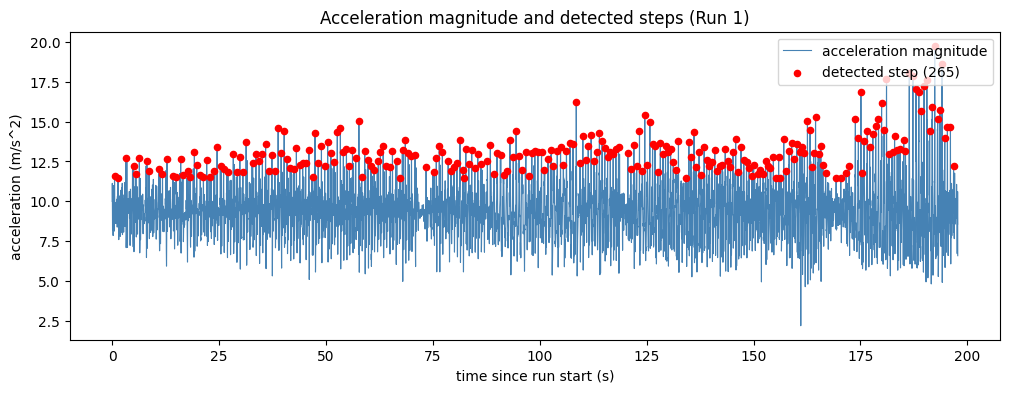

In [2]:
steps = imu.detect_steps(run.accel)
print("detected steps :", len(steps))
print("cadence        : %.2f steps/s" % (len(steps) / run.duration_s))

viz.plot_acceleration_with_steps(run.accel, steps, run_id=1)
plt.show()

## Validating the step count against the reference

`Paths_references.xlsx` now records a step count per segment (derived from the
segment time and the walking pace), so its final `Sum_steps` is a near-ground-truth
total number of steps for each run. We compare our detected count against it.

In [3]:
rows = []
for run_id in [1, 2, 3, 4]:
    r = preprocessing.load_run(run_id, raw_dir=RAW)
    detected = len(imu.detect_steps(r.accel))
    reference_total = evaluation.load_reference(run_id, reference_file=REF).iloc[-1]["sum_steps"]
    rows.append({
        "run": run_id,
        "detected": detected,
        "reference": round(reference_total, 1),
        "ratio": round(detected / reference_total, 2),
    })
pd.DataFrame(rows)

,run,detected,reference,ratio
0,1,265,263.7,1.00
1,2,245,228.6,1.07
2,3,330,315.6,1.05
3,4,286,299.8,0.95


The detected counts land within a few percent of the reference (mean ratio ≈ 1.0),
so the step detector is well calibrated against ground truth.

## Step length (measured, from the reference)

The reference workbook also records a **measured step length of 65 cm**. We read it
directly and use it in the motion model, instead of guessing or inferring it.

In [4]:
step_length_m = evaluation.load_step_length_m(REF)
print("measured step length:", step_length_m, "m")
print("Run 1 total distance :", round(len(steps) * step_length_m, 1), "m")

measured step length: 0.65 m
Run 1 total distance : 172.2 m


## Heading from the gyroscope

The person turns about the vertical axis. We estimate the vertical direction from
gravity (the mean accelerometer vector) and project the gyroscope onto it to get
the yaw rate, then integrate it into a heading. A constant gyro bias is removed
(the median yaw rate), and the heading is anchored to the run's known start
direction (`initial_heading`).

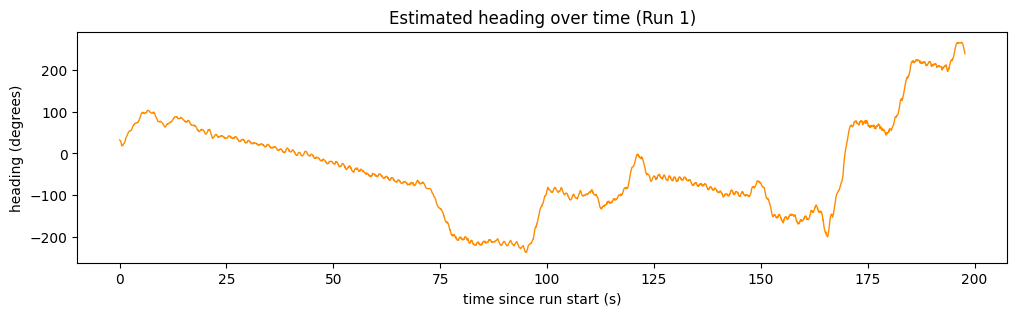

In [5]:
gravity = imu.estimate_gravity_direction(run.accel)
heading = imu.heading_from_gyro(run.gyro, gravity,
                                initial_heading=cfg["initial_heading"])

viz.plot_heading(heading, run_id=1)
plt.show()

## The per-step motion table

For each step we record its time, the step length (0.65 m), the heading at that
time, and an angular uncertainty (`heading_sigma`). This is the "error-prone motion
sector" the assignment asks for and the motion input to the filter.

In [6]:
motion = imu.build_motion_table(run, initial_heading=cfg["initial_heading"])
motion.head()

,t_rel,step_length,heading,heading_sigma
0,0.523,0.65,0.323713,0.261799
1,1.333,0.65,0.529523,0.261799
2,3.170,0.65,1.139286,0.261799
3,4.982,0.65,1.606359,0.261799
4,5.515,0.65,1.680204,0.261799


## Dead-reckoning sanity check

Walking step-by-step along the headings, with no map or Bluetooth, gives a
dead-reckoning path. It drifts over a few minutes (residual heading error) — which
is exactly why the particle filter later adds the map and Bluetooth — but its
overall shape should look like corridor walking.

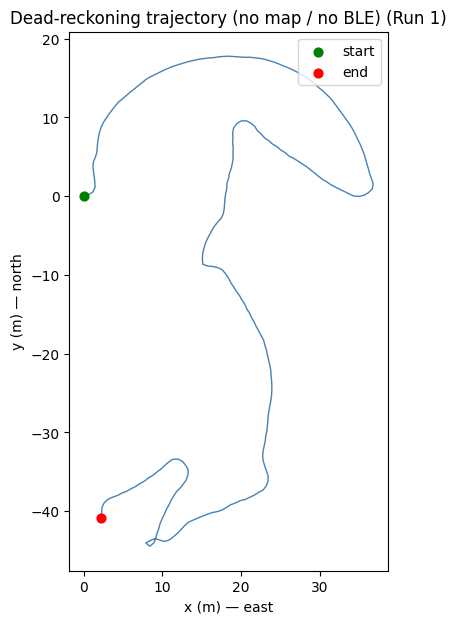

In [7]:
dead_reckoning = imu.dead_reckoning(motion, start=cfg["start"])
viz.plot_dead_reckoning(dead_reckoning, run_id=1)
plt.show()

## Per-run initial heading (decision D11)

The gyro gives only *relative* heading; its absolute anchor depends on how the
phone sat in the pocket (an unknown per-run yaw offset). Leaving it at 0 (east) for
every run launched non-eastward runs the wrong way. We calibrate the initial
heading by aligning each run's first straight corridor leg to the known corridor
axis, and store the result in `preprocessing.RUN_START`.

In [8]:
start_conditions = pd.DataFrame([
    {"run": run_id,
     "start_x": cfg_i["start"][0], "start_y": cfg_i["start"][1],
     "floor": cfg_i["floor"],
     "initial_heading_deg": round(np.degrees(cfg_i["initial_heading"]), 1)}
    for run_id, cfg_i in preprocessing.RUN_START.items()
])
start_conditions

,run,start_x,start_y,floor,initial_heading_deg
0,1,0.0,0.0,0,32.1
1,2,17.5,0.0,0,10.4
2,3,33.0,0.0,0,-132.3
3,4,2.0,0.0,0,147.4


Runs 1 and 3 improve markedly with the calibrated heading; Runs 2 and 4 have weak
anchors (short/under-counted leg, and floor-0 walking only at the run's end) — an
honest limitation documented in D11.